# 📞 CallMeMaybe — Análise de Desempenho Operacional

Este notebook foi desenvolvido para analisar o desempenho operacional da CallMeMaybe a partir dos dados de chamadas. 

A análise começa pela compreensão da qualidade e consistência das informações, passa pela investigação do comportamento das chamadas inbound e outbound, e explora como interações internas e externas moldam a experiência do cliente. 

A partir daí, construímos KPIs que revelam padrões de produtividade, identificamos operadores que se destacam — positiva ou negativamente — e desenvolvemos um score de ineficiência que sintetiza os principais sinais de alerta. Por fim, aplicamos testes estatísticos para validar se as diferenças observadas entre grupos são reais ou apenas ruído. 

O resultado é uma visão clara, orientada a dados, que apoia decisões operacionais e priorização de melhorias.


---
## 1. Imports e Configurações


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None) # Mostra todas as colunas do DataFrame
sns.set(style='whitegrid', palette='muted') # Configura o estilo do Seaborn para gráficos mais limpos   
%matplotlib inline  
# Permite que os gráficos sejam exibidos diretamente no Jupyter Notebook

### 📘 1.1 Dicionário de Dados

A tabela abaixo descreve as principais variáveis utilizadas na análise.  
As variáveis marcadas como *(derivada)* são criadas durante o processamento dos dados.

| Coluna                | Descrição                                                                 |
|-----------------------|---------------------------------------------------------------------------|
| `date`                | Data da chamada (formato original do dataset)                             |
| `user_id`             | Identificador do cliente                                                  |
| `operator_id`         | Identificador do operador responsável                                     |
| `direction`           | Direção da chamada (`in` = inbound, `out` = outbound)                     |
| `internal`            | Indica se a chamada é interna (`True`) ou externa (`False`)               |
| `calls_count`         | Quantidade de chamadas agregadas naquele registro                         |
| `call_duration`       | Tempo efetivo de atendimento (em segundos)                                |
| `total_call_duration` | Tempo total da chamada (espera + atendimento)                             |
| `is_missed_call`      | Indica se a chamada foi perdida (`1`) ou atendida (`0`)                   |
| `waiting_time` *(derivada)* | Tempo de espera antes do atendimento (`total_call_duration - call_duration`) |
| `day` *(derivada)*    | Data sem horário, extraída de `date`                                      |

Esse dicionário resume apenas as variáveis relevantes para a análise, mantendo o foco na clareza e na interpretação dos resultados.



---
## 2. Carregamento dos Dados


In [25]:
df_calls = pd.read_csv('telecom_dataset_new.csv')
df_clients = pd.read_csv('telecom_clients.csv')

print('Shape df_calls:', df_calls.shape)
print('Shape df_clients:', df_clients.shape)
df_calls.head()

Shape df_calls: (53902, 9)
Shape df_clients: (732, 3)


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


---
## 3. Qualidade dos Dados


In [26]:
print('=== Tipos de dados ===')
print(df_calls.dtypes)

print('\n=== Valores ausentes ===')
missing = df_calls.isnull().sum()
missing_pct = (missing / len(df_calls) * 100).round(2)
display(pd.DataFrame({'Ausentes': missing, 'Percentual (%)': missing_pct}))

print('\n=== Estatísticas numéricas ===')
num_cols = ['calls_count', 'call_duration', 'total_call_duration']
num_cols = [c for c in num_cols if c in df_calls.columns]
display(df_calls[num_cols].describe())

=== Tipos de dados ===
user_id                  int64
date                       str
direction                  str
internal                object
operator_id            float64
is_missed_call            bool
calls_count              int64
call_duration            int64
total_call_duration      int64
dtype: object

=== Valores ausentes ===


,Ausentes,Percentual (%)
user_id,0,0.00
date,0,0.00
direction,0,0.00
internal,117,0.22
operator_id,8172,15.16
is_missed_call,0,0.00
calls_count,0,0.00
call_duration,0,0.00
total_call_duration,0,0.00



=== Estatísticas numéricas ===


,calls_count,call_duration,total_call_duration
count,53902.000000,53902.000000,53902.000000
mean,16.451245,866.684427,1157.133297
std,62.917170,3731.791202,4403.468763
min,1.000000,0.000000,0.000000
25%,1.000000,0.000000,47.000000
50%,4.000000,38.000000,210.000000
75%,12.000000,572.000000,902.000000
max,4817.000000,144395.000000,166155.000000


---
## 4. Limpeza e Processamento (5.1)

- Converter `date` para datetime
- Converter `operator_id` para inteiro
- Tratar valores ausentes em `internal` e `operator_id`
- Criar `waiting_time`
- Remover outliers extremos
- Padronizar categorias (`direction`, `internal`)


In [ ]:
# 4.1 Conversão de tipos
df_calls['date'] = pd.to_datetime(df_calls['date'], errors='coerce') # Converte a coluna 'date' para datetime, tratando erros como NaT
df_calls['day'] = df_calls['date'].dt.date # Extrai apenas a parte da data (sem hora) para uma nova coluna 'day'
df_calls = df_calls.astype({'operator_id': 'Int64'}, errors='ignore') # Converte a coluna 'operator_id' para inteiro, permitindo valores ausentes (NaN) como <NA>

print(df_calls.dtypes)

user_id                                    int64
date                   datetime64[us, UTC+03:00]
direction                                    str
internal                                  object
operator_id                                Int64
is_missed_call                              bool
calls_count                                int64
call_duration                              int64
total_call_duration                        int64
waiting_time                               int64
day                                       object
dtype: object


In [ ]:
# 4.2 Tratamento de valores ausentes e padronização de categorias
df_calls['internal'] = df_calls['internal'].fillna(False) # Preenche valores ausentes em 'internal' com False, assumindo que chamadas sem essa informação não são internas

df_calls['direction'] = df_calls['direction'].str.lower().str.strip() # Padroniza a coluna 'direction' para minúsculas e remove espaços em branco

df_ops = df_calls.dropna(subset=['operator_id']).copy() # Cria um DataFrame apenas com registros que possuem 'operator_id' preenchido

print(f'Registros totais:          {len(df_calls):,}')
print(f'Registros com operator_id: {len(df_ops):,}')
print(f'Sem operator_id:           {len(df_calls) - len(df_ops):,}')

Registros totais:          53,902
Registros com operator_id: 45,730
Sem operator_id:           8,172


In [ ]:
# 4.3 Variável derivada: waiting_time

df_calls['waiting_time'] = df_calls['total_call_duration'] - df_calls['call_duration'] # Calcula o tempo de espera como a diferença entre total_call_duration e call_duration
df_calls['waiting_time'] = df_calls['waiting_time'].clip(lower=0) # Garante que o tempo de espera não seja negativo, definindo valores menores que 0 como 0

df_ops['waiting_time'] = df_ops['total_call_duration'] - df_ops['call_duration'] # Calcula o tempo de espera para o DataFrame filtrado por operator_id
df_ops['waiting_time'] = df_ops['waiting_time'].clip(lower=0) # Garante que o tempo de espera não seja negativo para o DataFrame filtrado por operator_id

display(df_calls[['call_duration', 'total_call_duration', 'waiting_time']].describe()) # Exibe estatísticas descritivas para as colunas de duração e tempo de espera


,call_duration,total_call_duration,waiting_time
count,53902.000000,53902.000000,53902.000000
mean,866.684427,1157.133297,290.448870
std,3731.791202,4403.468763,1127.905654
min,0.000000,0.000000,0.000000
25%,0.000000,47.000000,17.000000
50%,38.000000,210.000000,55.000000
75%,572.000000,902.000000,201.000000
max,144395.000000,166155.000000,46474.000000


In [31]:
# 4.4 Remoção de outliers extremos (IQR) em durações
for col in ['call_duration', 'total_call_duration', 'waiting_time']: # Itera sobre as colunas de duração e tempo de espera para identificar e remover outliers usando o método do IQR
    if col in df_calls.columns:
        q1 = df_calls[col].quantile(0.25) # Calcula o primeiro quartil (Q1) para a coluna atual
        q3 = df_calls[col].quantile(0.75) # Calcula o terceiro quartil (Q3) para a coluna atual
        iqr = q3 - q1 # Calcula o intervalo interquartil (IQR) como a diferença entre Q3 e Q1
        upper = q3 + 3 * iqr # Define o limite superior para identificar outliers como Q3 + 3 vezes o IQR
        before = len(df_calls) # Armazena o número de registros antes da remoção de outliers
        df_calls = df_calls[df_calls[col] <= upper] # Filtra o DataFrame para manter apenas os registros onde o valor da coluna atual é menor ou igual ao limite superior, removendo os outliers
        after = len(df_calls) # Armazena o número de registros após a remoção de outliers
        print(f'{col}: removidos {before - after} outliers (limite {upper:.1f})')

# Reajustar df_ops após remoção de outliers
if 'operator_id' in df_calls.columns: 
    # Refiltra o DataFrame para criar df_ops apenas com registros que possuem 'operator_id' preenchido, garantindo que ele esteja atualizado após a remoção de outliers
    df_ops = df_calls.dropna(subset=['operator_id']).copy() 
else:
    # Se a coluna 'operator_id' não existir, mantém df_ops igual a df_calls para evitar erros
    df_ops = df_calls.copy() 

call_duration: removidos 2397 outliers (limite 1264.0)
total_call_duration: removidos 904 outliers (limite 1243.0)
waiting_time: removidos 1719 outliers (limite 300.0)


---
## 5. Análise Exploratória de Dados (5.2)

Nesta seção, exploramos:
- distribuições de duração e espera;
- comparação inbound vs outbound;
- comparação internas vs externas;
- visualizações essenciais (histogramas, boxplots, heatmap).


### 5.1 Distribuições de Duração e Espera


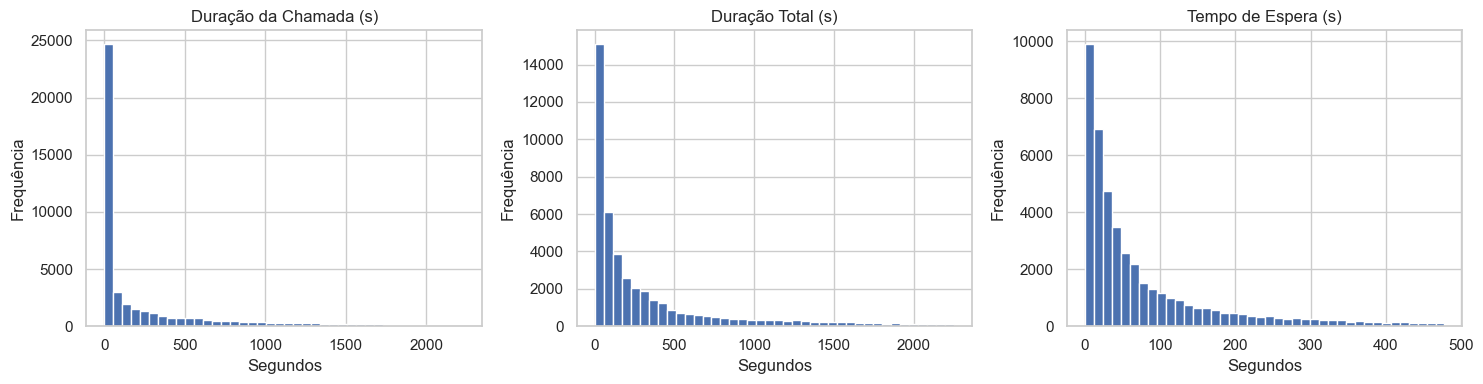

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4)) # Cria uma figura com 3 subplots para os histogramas de call_duration, total_call_duration e waiting_time
cols = ['call_duration', 'total_call_duration', 'waiting_time']
labels = ['Duração da Chamada (s)', 'Duração Total (s)', 'Tempo de Espera (s)']

for ax, col, label in zip(axes, cols, labels): # Itera sobre os eixos, colunas e rótulos para criar os histogramas
    if col in df_calls.columns:
        ax.hist(df_calls[col].dropna(), bins=40, color='#4C72B0', edgecolor='white')
        ax.set_title(label)
        ax.set_xlabel('Segundos')
        ax.set_ylabel('Frequência')

plt.tight_layout()
plt.show()

### 5.2 Comparação Inbound vs Outbound


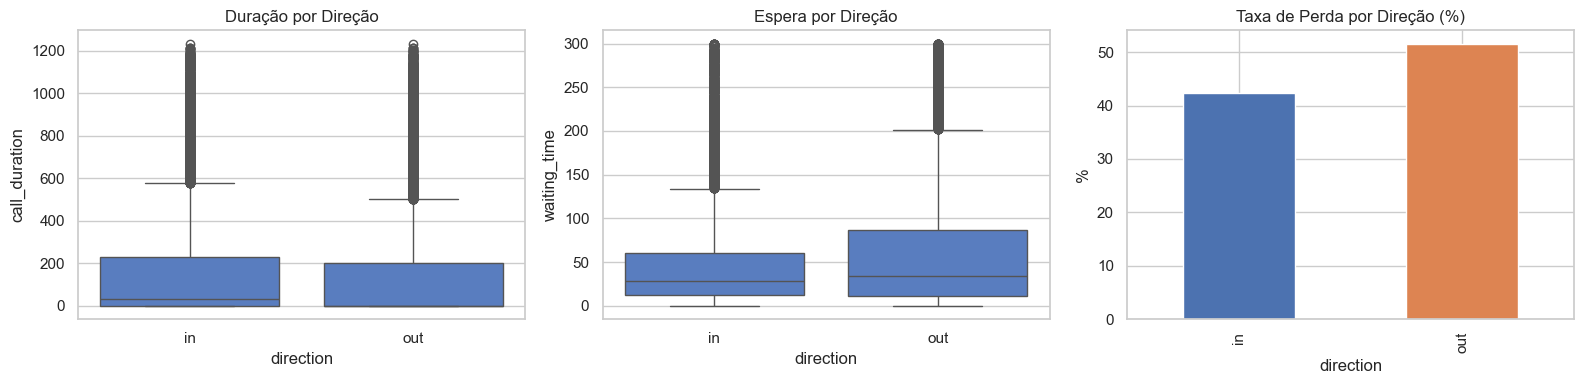

In [ ]:
if 'direction' in df_calls.columns:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    sns.boxplot(data=df_calls, x='direction', y='call_duration', ax=axes[0]) # Cria um boxplot para comparar a duração das chamadas por direção (entrada vs saída)
    axes[0].set_title('Duração por Direção') 

    sns.boxplot(data=df_calls, x='direction', y='waiting_time', ax=axes[1]) # Cria um boxplot para comparar o tempo de espera por direção (entrada vs saída)
    axes[1].set_title('Espera por Direção')

    if 'is_missed_call' in df_calls.columns:
        missed_dir = df_calls.groupby('direction')['is_missed_call'].mean() * 100 # Calcula a taxa de chamadas perdidas por direção, multiplicando por 100 para obter o percentual
        missed_dir.plot(kind='bar', ax=axes[2], color=['#4C72B0', '#DD8452'])
        axes[2].set_title('Taxa de Perda por Direção (%)')
        axes[2].set_ylabel('%')

    plt.tight_layout()
    plt.show()
else:
    print('Coluna direction não encontrada.')

### 5.3 Comparação Internas vs Externas


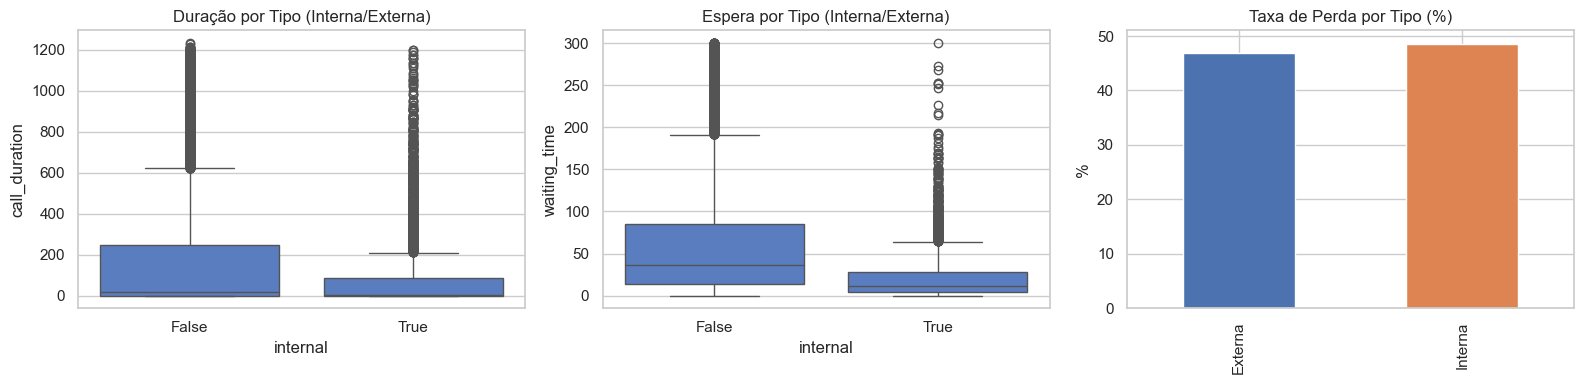

In [34]:
if 'internal' in df_calls.columns:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    sns.boxplot(data=df_calls, x='internal', y='call_duration', ax=axes[0])
    axes[0].set_title('Duração por Tipo (Interna/Externa)')

    sns.boxplot(data=df_calls, x='internal', y='waiting_time', ax=axes[1])
    axes[1].set_title('Espera por Tipo (Interna/Externa)')

    if 'is_missed_call' in df_calls.columns:
        # Calcula a taxa de chamadas perdidas por tipo (interna vs externa), multiplicando por 100 para obter o percentual
        missed_type = df_calls.groupby('internal')['is_missed_call'].mean() * 100 
        # Renomeia os índices para 'Externa' e 'Interna' se houver exatamente 2 categorias, caso contrário mantém os índices originais
        missed_type.index = ['Externa', 'Interna'] if len(missed_type.index) == 2 else missed_type.index 
        missed_type.plot(kind='bar', ax=axes[2], color=['#4C72B0', '#DD8452'])
        axes[2].set_title('Taxa de Perda por Tipo (%)')
        axes[2].set_ylabel('%')

    plt.tight_layout()
    plt.show()
else:
    print('Coluna internal não encontrada.')

### 5.4 Heatmap de Correlação (Variáveis Numéricas)


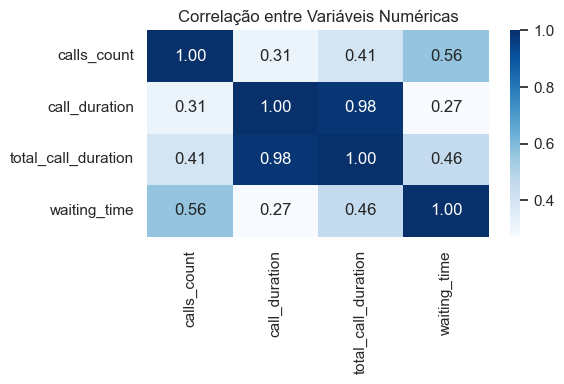

In [11]:
num_cols = ['calls_count', 'call_duration', 'total_call_duration', 'waiting_time']
num_cols = [c for c in num_cols if c in df_calls.columns]

corr = df_calls[num_cols].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlação entre Variáveis Numéricas')
plt.tight_layout()
plt.show()

---
## 6. KPIs por Operador, Dia e Cliente


### 6.1 KPIs por Operador


In [12]:
kpi_ops = df_ops.groupby('operator_id').agg(
    total_calls=('is_missed_call', 'count'),
    missed_calls=('is_missed_call', 'sum'),
    avg_waiting_time=('waiting_time', 'mean'),
    avg_call_duration=('call_duration', 'mean'),
    outbound_calls=('direction', lambda x: (x == 'out').sum()),
    inbound_calls=('direction', lambda x: (x == 'in').sum()),
    internal_calls=('internal', 'sum'),
    total_calls_count=('calls_count', 'sum')
).reset_index()

kpi_ops['missed_call_rate'] = kpi_ops['missed_calls'] / kpi_ops['total_calls']
kpi_ops['outbound_activity'] = kpi_ops['outbound_calls'] / kpi_ops['total_calls']

print(f'Operadores únicos analisados: {len(kpi_ops)}')
kpi_ops.head()

Operadores únicos analisados: 1073


,operator_id,total_calls,missed_calls,avg_waiting_time,avg_call_duration,outbound_calls,inbound_calls,internal_calls,total_calls_count,missed_call_rate,outbound_activity
0,879896,113,46,53.654867,224.238938,90,23,16,438,0.407080,0.796460
1,879898,133,47,115.646617,176.127820,69,64,16,979,0.353383,0.518797
2,880020,22,7,15.181818,104.090909,14,8,3,54,0.318182,0.636364
3,880022,73,32,52.739726,184.684932,65,8,8,203,0.438356,0.890411
4,880026,161,93,109.484472,468.062112,142,19,14,1498,0.577640,0.881988


#### Ranking — Operadores com maior taxa de chamadas perdidas e maior tempo de espera


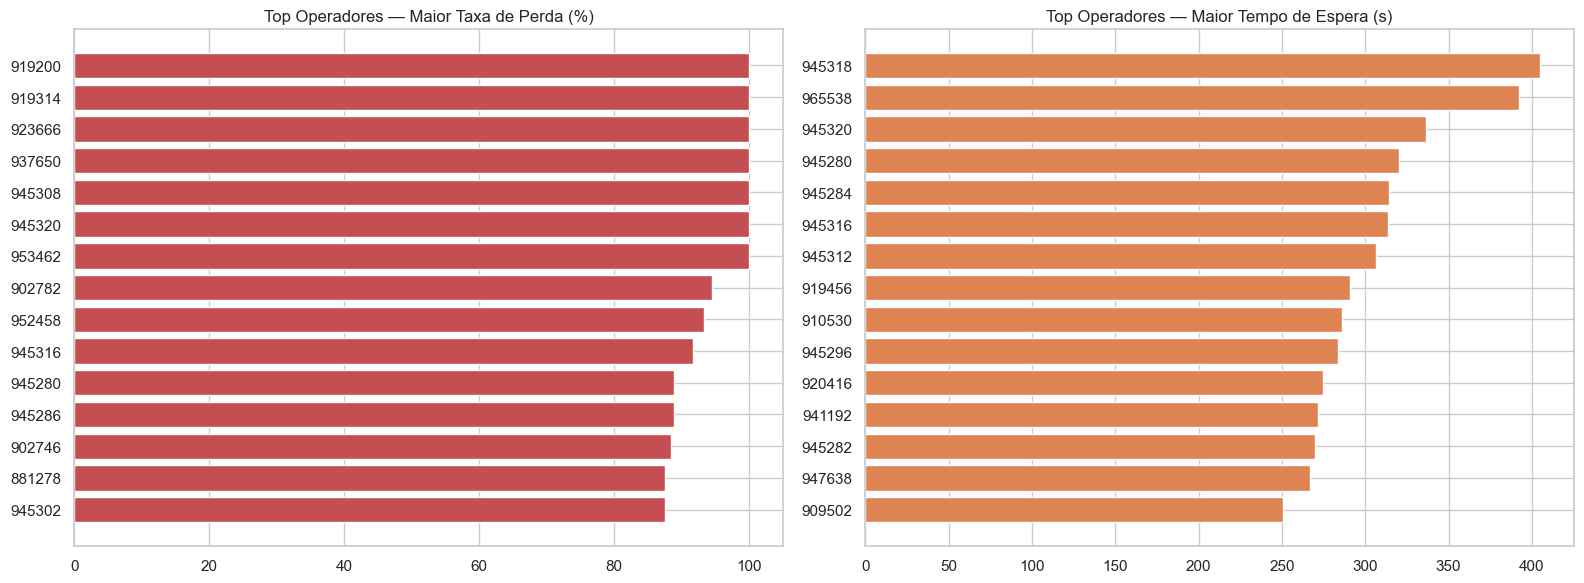

In [13]:
min_calls = kpi_ops['total_calls'].quantile(0.25)
kpi_filtered = kpi_ops[kpi_ops['total_calls'] >= min_calls].copy()

top_missed = kpi_filtered.nlargest(15, 'missed_call_rate')
top_wait = kpi_filtered.nlargest(15, 'avg_waiting_time')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_missed['operator_id'].astype(str), top_missed['missed_call_rate'] * 100, color='#C44E52')
axes[0].set_title('Top Operadores — Maior Taxa de Perda (%)')
axes[0].invert_yaxis()

axes[1].barh(top_wait['operator_id'].astype(str), top_wait['avg_waiting_time'], color='#DD8452')
axes[1].set_title('Top Operadores — Maior Tempo de Espera (s)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### 6.2 KPIs por Dia


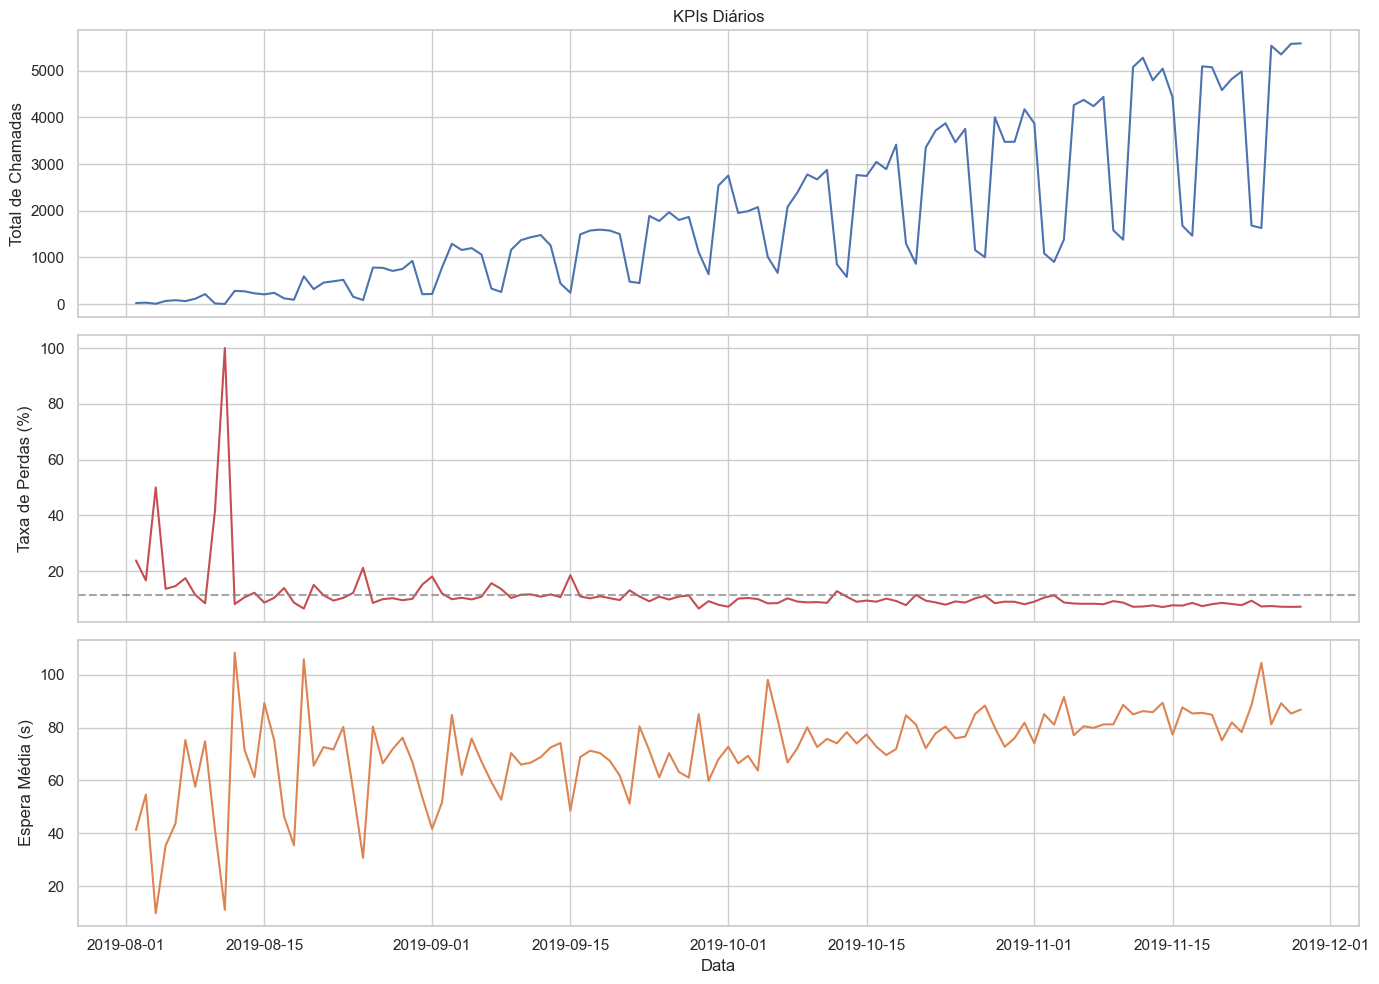

In [14]:
kpi_day = df_calls.groupby('day').agg(
    total_calls=('calls_count', 'sum'),
    missed_calls=('is_missed_call', 'sum'),
    avg_waiting=('waiting_time', 'mean')
).reset_index()

kpi_day['missed_rate'] = kpi_day['missed_calls'] / kpi_day['total_calls'] * 100
kpi_day['day'] = pd.to_datetime(kpi_day['day'])

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(kpi_day['day'], kpi_day['total_calls'], color='#4C72B0')
axes[0].set_ylabel('Total de Chamadas')
axes[0].set_title('KPIs Diários')

axes[1].plot(kpi_day['day'], kpi_day['missed_rate'], color='#C44E52')
axes[1].set_ylabel('Taxa de Perdas (%)')
axes[1].axhline(kpi_day['missed_rate'].mean(), linestyle='--', color='gray', alpha=0.7)

axes[2].plot(kpi_day['day'], kpi_day['avg_waiting'], color='#DD8452')
axes[2].set_ylabel('Espera Média (s)')
axes[2].set_xlabel('Data')

plt.tight_layout()
plt.show()

### 6.3 KPIs por Cliente


In [15]:
kpi_client = df_calls.groupby('user_id').agg(
    total_calls=('is_missed_call', 'count'),
    missed_calls=('is_missed_call', 'sum'),
    avg_waiting_time=('waiting_time', 'mean')
).reset_index()

kpi_client['missed_rate'] = kpi_client['missed_calls'] / kpi_client['total_calls']
kpi_client = kpi_client.merge(df_clients, on='user_id', how='left')

print(f'Clientes únicos analisados: {len(kpi_client)}')
kpi_client.head()

Clientes únicos analisados: 307


,user_id,total_calls,missed_calls,avg_waiting_time,missed_rate,tariff_plan,date_start
0,166377,472,247,99.908898,0.523305,B,2019-08-01
1,166391,20,15,33.450000,0.750000,C,2019-08-01
2,166392,107,54,38.757009,0.504673,C,2019-08-01
3,166399,23,10,25.521739,0.434783,C,2019-08-01
4,166405,700,348,108.248571,0.497143,B,2019-08-02


---
## 7. Score de Ineficiência do Operador


In [16]:
def minmax(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

kpi_filtered['score_missed'] = minmax(kpi_filtered['missed_call_rate'])
kpi_filtered['score_wait'] = minmax(kpi_filtered['avg_waiting_time'])
kpi_filtered['score_outbound'] = 1 - minmax(kpi_filtered['outbound_activity'])

W_MISSED = 0.50
W_WAIT = 0.35
W_OUTBOUND = 0.15

kpi_filtered['inefficiency_score'] = (
    W_MISSED * kpi_filtered['score_missed'] +
    W_WAIT * kpi_filtered['score_wait'] +
    W_OUTBOUND * kpi_filtered['score_outbound']
)

kpi_filtered = kpi_filtered.sort_values('inefficiency_score', ascending=False).reset_index(drop=True)
kpi_filtered['rank'] = kpi_filtered.index + 1

kpi_filtered[['rank', 'operator_id', 'total_calls', 'missed_call_rate', 'avg_waiting_time', 'outbound_activity', 'inefficiency_score']].head(15)

,rank,operator_id,total_calls,missed_call_rate,avg_waiting_time,outbound_activity,inefficiency_score
0,1,945320,8,1.000000,336.375000,1.0,0.790621
1,2,965538,5,0.800000,392.000000,1.0,0.738752
2,3,945316,12,0.916667,313.916667,1.0,0.729522
3,4,945318,4,0.750000,405.000000,1.0,0.725000
4,5,945280,9,0.888889,320.000000,1.0,0.720897
5,6,919200,4,1.000000,224.000000,1.0,0.693387
6,7,945284,5,0.800000,314.200000,1.0,0.671434
7,8,945296,19,0.842105,283.894737,1.0,0.666264
8,9,923666,6,1.000000,186.000000,1.0,0.660507
9,10,945308,4,1.000000,183.000000,1.0,0.657911


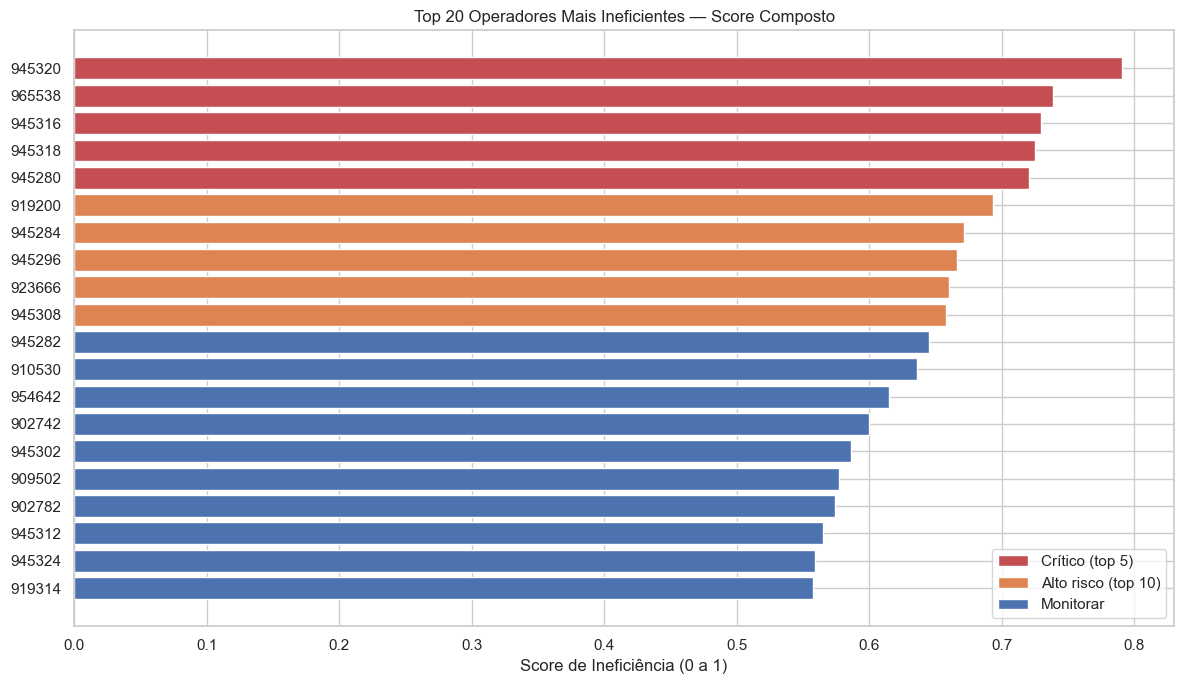

In [17]:
top20 = kpi_filtered.head(20).copy()
colors = ['#C44E52' if i < 5 else ('#DD8452' if i < 10 else '#4C72B0') for i in range(len(top20))]

plt.figure(figsize=(12, 7))
plt.barh(top20['operator_id'].astype(str), top20['inefficiency_score'], color=colors)
plt.xlabel('Score de Ineficiência (0 a 1)')
plt.title('Top 20 Operadores Mais Ineficientes — Score Composto')
plt.gca().invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#C44E52', label='Crítico (top 5)'),
    Patch(facecolor='#DD8452', label='Alto risco (top 10)'),
    Patch(facecolor='#4C72B0', label='Monitorar')
]
plt.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

---
## 8. Testes de Hipótese

Hipóteses avaliadas:
- **H1**: Operadores ineficientes têm maior taxa de chamadas perdidas.
- **H2**: Operadores ineficientes têm maior tempo de espera.
- **H3**: Operadores ineficientes fazem menos chamadas outbound.
- **H4**: Chamadas internas têm duração diferente das externas.


In [18]:
threshold = kpi_filtered['inefficiency_score'].quantile(0.75)
inef_ids = kpi_filtered[kpi_filtered['inefficiency_score'] >= threshold]['operator_id']
ef_ids   = kpi_filtered[kpi_filtered['inefficiency_score'] <  threshold]['operator_id']

group_inef = df_ops[df_ops['operator_id'].isin(inef_ids)]
group_ef   = df_ops[df_ops['operator_id'].isin(ef_ids)]

print('Operadores ineficientes:', len(inef_ids))
print('Operadores eficientes:', len(ef_ids))

Operadores ineficientes: 214
Operadores eficientes: 639


### H1 — Operadores ineficientes têm maior taxa de chamadas perdidas?

In [19]:
stat1, pval1 = stats.mannwhitneyu(
    group_inef['is_missed_call'],
    group_ef['is_missed_call'],
    alternative='greater'
)

print('H1 — Taxa de chamadas perdidas')
print(f'Média ineficientes: {group_inef["is_missed_call"].mean():.3f}')
print(f'Média eficientes:   {group_ef["is_missed_call"].mean():.3f}')
print(f'U-stat: {stat1:.0f}, p-value: {pval1:.4f}')
print('Conclusão:', 'Rejeita H0 — diferença significativa' if pval1 < 0.05 else 'Não rejeita H0')

H1 — Taxa de chamadas perdidas
Média ineficientes: 0.490
Média eficientes:   0.284
U-stat: 161088081, p-value: 0.0000
Conclusão: Rejeita H0 — diferença significativa


### H2 — Operadores ineficientes têm maior tempo de espera?

In [20]:
stat2, pval2 = stats.mannwhitneyu(
    group_inef['waiting_time'],
    group_ef['waiting_time'],
    alternative='greater'
)

print('H2 — Tempo de espera')
print(f'Mediana ineficientes: {group_inef["waiting_time"].median():.1f}s')
print(f'Mediana eficientes:   {group_ef["waiting_time"].median():.1f}s')
print(f'U-stat: {stat2:.0f}, p-value: {pval2:.4f}')
print('Conclusão:', 'Rejeita H0 — diferença significativa' if pval2 < 0.05 else 'Não rejeita H0')

H2 — Tempo de espera
Mediana ineficientes: 98.0s
Mediana eficientes:   31.0s
U-stat: 182929348, p-value: 0.0000
Conclusão: Rejeita H0 — diferença significativa


### H3 — Operadores ineficientes fazem menos chamadas outbound?

In [21]:
stat3, pval3 = stats.mannwhitneyu(
    kpi_filtered[kpi_filtered['operator_id'].isin(inef_ids)]['outbound_activity'],
    kpi_filtered[kpi_filtered['operator_id'].isin(ef_ids)]['outbound_activity'],
    alternative='less'
)

print('H3 — Atividade outbound')
print(f'Média ineficientes: {kpi_filtered[kpi_filtered["operator_id"].isin(inef_ids)]["outbound_activity"].mean():.3f}')
print(f'Média eficientes:   {kpi_filtered[kpi_filtered["operator_id"].isin(ef_ids)]["outbound_activity"].mean():.3f}')
print(f'U-stat: {stat3:.0f}, p-value: {pval3:.4f}')
print('Conclusão:', 'Rejeita H0 — diferença significativa' if pval3 < 0.05 else 'Não rejeita H0')

H3 — Atividade outbound
Média ineficientes: 0.807
Média eficientes:   0.562
U-stat: 96403, p-value: 1.0000
Conclusão: Não rejeita H0


### H4 — Chamadas internas têm duração diferente das externas?

In [22]:
if 'internal' in df_calls.columns:
    dur_int = df_calls[df_calls['internal'] == True]['call_duration']
    dur_ext = df_calls[df_calls['internal'] == False]['call_duration']

    stat4, pval4 = stats.mannwhitneyu(dur_int, dur_ext, alternative='two-sided')

    print('H4 — Duração interna vs externa')
    print(f'Mediana internas: {dur_int.median():.1f}s')
    print(f'Mediana externas: {dur_ext.median():.1f}s')
    print(f'U-stat: {stat4:.0f}, p-value: {pval4:.4f}')
    print('Conclusão:', 'Rejeita H0 — diferença significativa' if pval4 < 0.05 else 'Não rejeita H0')
else:
    print('Coluna internal não encontrada para H4.')

H4 — Duração interna vs externa
Mediana internas: 6.0s
Mediana externas: 32.0s
U-stat: 97735146, p-value: 0.0000
Conclusão: Rejeita H0 — diferença significativa


---
## 9. Conclusões e Recomendações

### Principais Achados
- A taxa de chamadas perdidas e o tempo de espera são os indicadores mais sensíveis de ineficiência.
- Operadores com maior score de ineficiência concentram maior taxa de perda e maior tempo de espera.
- Diferenças entre inbound vs outbound e internas vs externas ajudam a entender o contexto operacional.

### Recomendações
- Focar ações imediatas nos operadores com maior score de ineficiência (top 5).
- Revisar processos que geram maior tempo de espera.
- Monitorar mensalmente os KPIs e o score composto.
- Investigar qualitativamente (escuta de chamadas) os casos mais críticos.
